# Discussion of Trolley problem
(see `math/2_deterministic.typ`)

In [ ]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from rich import print


@dataclass
class TrolleyProblem:
    n0: int = 3
    n1: int = 1
    ms: int = 1
    m0: int = 0


def U_0(tp: TrolleyProblem):
    return -(tp.n0 / (1 + tp.m0)) - (tp.n1 / (1 + tp.ms + tp.m0))


def U_1(tp: TrolleyProblem):
    return -(tp.n0 / (1 + tp.ms)) - tp.n1


# Different examples

# classic trolley problem
classic = TrolleyProblem(m0=0)
print(f"Classic trolley probled: U_0:{U_0(classic)}, U_1: {U_1(classic)}")

# trolley problem with cultural norm
norm = TrolleyProblem(m0=1)
print(f"Norm trolley problem: U_0:{U_0(norm)}, U_1: {U_1(norm)}")

# trolley problem with strong preference for survival
strong_survival = TrolleyProblem(n0=5, n1=1, ms=1_000, m0=5)
print(
    f"Strong trolley problem: U_0:{U_0(strong_survival)}, U_1: {U_1(strong_survival)}"
)

Classic trolley probled: U_0:-3.5, U_1: -2.5

Norm trolley problem: U_0:-1.8333333333333333, U_1: -2.5

Strong trolley problem: U_0:-0.8343273691186216, U_1: -1.004995004995005

/tmp/ipykernel_10480/1735800832.py:12: RuntimeWarning: invalid value encountered in divide
  RHS = numerator / denominator


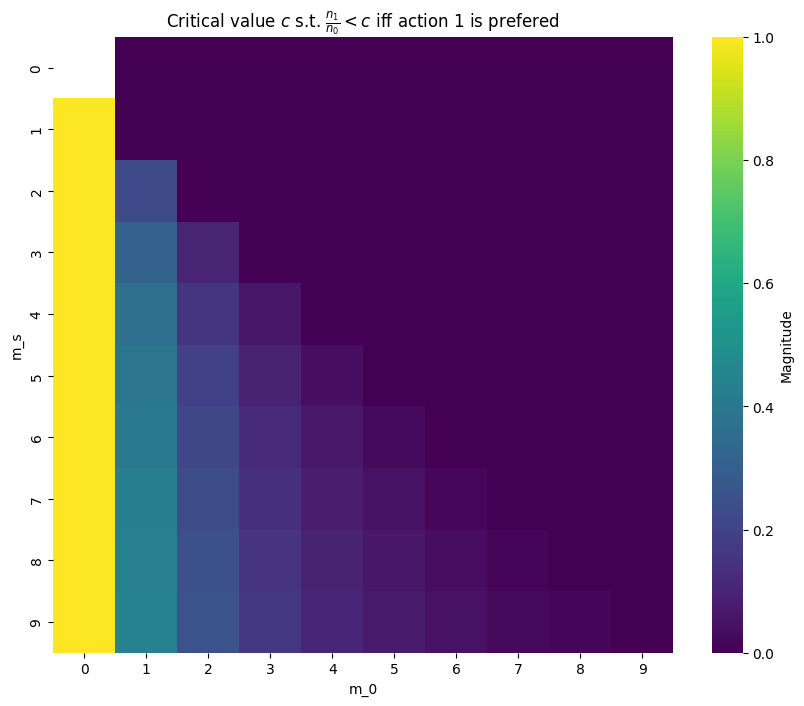

In [24]:
# Decision Boundary: For which values of n_1/n_0 is action 1 preferrd over 0


def plot_rhs_heatmap():
    m_0 = np.arange(10)
    m_s = np.arange(10)
    M_0, M_s = np.meshgrid(m_0, m_s)

    # Compute RHS
    numerator = (M_s - M_0) * (1 + M_s + M_0)
    denominator = (1 + M_0) * (1 + M_s) * (M_s + M_0)
    RHS = numerator / denominator

    plt.figure(figsize=(10, 8))
    sns.heatmap(RHS, cmap="viridis", cbar_kws={"label": "Magnitude"}, vmin=0, vmax=1)
    plt.xlabel("m_0")
    plt.ylabel("m_s")
    plt.title(r"Critical value $c$ s.t. $\frac{n_1}{n_0} < c$ iff action 1 is prefered")
    plt.show()


plot_rhs_heatmap()

In [ ]:
# Given, m_0, n_0, n_1 how high does m_s have to be for action 1 to be preffered


def plot_quadratic_function_interactive(n0=1.0, n1=0.5, m0=2.0):
    A = n0 - n1 * (1 + m0)
    B = n0 - n1 * (1 + m0) ** 2
    C = -m0 * (1 + m0) * (n0 + n1)

    # Generate a wide range of m_s values
    m_s = np.linspace(-10, 10, 1000)
    f_ms = A * m_s**2 + B * m_s + C

    # Filter for m_s > -0.5 and f(m_s) > -1
    mask = (m_s > -0.5) & (f_ms > -1)
    m_s_filtered = m_s[mask]
    f_ms_filtered = f_ms[mask]

    plt.figure(figsize=(8, 5))
    plt.plot(
        m_s_filtered,
        f_ms_filtered,
        label=rf"$\Delta(m_s)$ = {A:.2f} m_s² + {B:.2f} m_s + {C:.2f}",
    )
    plt.xlabel("m_s")
    plt.ylabel("f(m_s)")
    plt.title(r"$\Delta = U_1 - U_0$ for varying $m_s$")
    plt.grid(True)
    plt.legend()
    plt.show()


# Create interactive sliders
interact(
    plot_quadratic_function_interactive,
    n0=FloatSlider(min=0, max=10, step=1, value=1.0, description="n₀"),
    n1=FloatSlider(min=0, max=10, step=1, value=0.5, description="n₁"),
    m0=FloatSlider(min=0, max=10, step=1, value=2.0, description="m₀"),
)

interactive(children=(FloatSlider(value=1.0, description='n₀', max=10.0, step=1.0), FloatSlider(value=0.5, des…

<function __main__.plot_quadratic_function_interactive(n0=1.0, n1=0.5, m0=2.0)>